In [1]:
import anndata as ad
from collections import Counter
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import scanpy as sc
from scipy.stats import kruskal, mannwhitneyu, false_discovery_control
from skbio.stats.composition import clr, multiplicative_replacement
import seaborn as sns

import matplotlib as mpl

mpl.rcParams["pdf.use14corefonts"] = True
mpl.rcParams['pdf.fonttype'] = 42

In [2]:
main_path = os.getcwd()
import sys
sys.path.append(main_path)

from analysis.libraries.data_processing import match_core_to_ACA, generate_frequency_vector
from analysis.libraries.clinical import load_clinical

### Preprocessing

In [4]:
adata = ad.read_h5ad(os.path.join(main_path, 'data/LATTICeA_io_adata_ssl_leiden_224px_fold0.h5ad'))
adata.obs = adata.obs.replace({'CKPAN':'panCK', 'Negative':'Unclassifiable'})
adata.obs

/mnt/cephfs/home/users/krakovic/.conda/envs/scpy/lib/python3.10/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


,CellX,CellY,Core,TMA,Core_ID,Region,AreaCell,t_CellX,t_CellY,kmeans_5,kmeans_10,cell_lineage,y_start,y_stop,x_start,x_stop,leiden
0,8526.375294,-47209.294961,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,92.647581,223.004094,-134.923761,0,0,panCK,111.3728,222.7456,222.7456,334.1184,2
1,8502.780534,-47222.466136,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,106.730014,199.409334,-148.094936,0,0,panCK,111.3728,222.7456,111.3728,222.7456,NaN
2,8510.929662,-47224.074935,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,42.000237,207.558462,-149.703735,0,9,panCK,111.3728,222.7456,111.3728,222.7456,NaN
3,8517.623256,-47224.496313,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,72.882764,214.252056,-150.125113,0,0,panCK,111.3728,222.7456,111.3728,222.7456,NaN
4,8522.685445,-47229.076912,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Stroma,35.082551,219.314245,-154.705712,1,8,CD68,111.3728,222.7456,111.3728,222.7456,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16815638,8311.875731,-53930.612326,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,92.153461,717.504531,-1115.241126,2,4,CD4,1113.7280,1225.1008,668.2368,779.6096,NaN
16815639,8433.799791,-53929.827897,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,58.059151,839.428591,-1114.456697,1,8,CD68,1113.7280,1225.1008,779.6096,890.9824,NaN
16815640,8299.651795,-53932.267364,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,98.577027,705.280595,-1116.896164,1,8,CD68,1113.7280,1225.1008,668.2368,779.6096,NaN
16815641,8411.888971,-53932.588400,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Tumour,104.259412,817.517771,-1117.217200,1,2,CD68,1113.7280,1225.1008,779.6096,890.9824,NaN


In [5]:
cores_df = pd.read_csv(os.path.join(main_path, 'data/metadata/tma-core-metadata.csv'))    

bioclavis_cores = adata.obs['Core_ID'].unique()
bioclavis_core_dict = dict()

for core in bioclavis_cores:
    bioclavis_core_dict[core] = match_core_to_ACA(core, cores_df)

adata.obs['samples'] = adata.obs['Core_ID'].map(bioclavis_core_dict)

# adata = adata[~adata.obs['leiden'].isna()]

adata.obs

,CellX,CellY,Core,TMA,Core_ID,Region,AreaCell,t_CellX,t_CellY,kmeans_5,kmeans_10,cell_lineage,y_start,y_stop,x_start,x_stop,leiden,samples
0,8526.375294,-47209.294961,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,92.647581,223.004094,-134.923761,0,0,panCK,111.3728,222.7456,222.7456,334.1184,2,ACA_1067
1,8502.780534,-47222.466136,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,106.730014,199.409334,-148.094936,0,0,panCK,111.3728,222.7456,111.3728,222.7456,NaN,ACA_1067
2,8510.929662,-47224.074935,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,42.000237,207.558462,-149.703735,0,9,panCK,111.3728,222.7456,111.3728,222.7456,NaN,ACA_1067
3,8517.623256,-47224.496313,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Tumour,72.882764,214.252056,-150.125113,0,0,panCK,111.3728,222.7456,111.3728,222.7456,NaN,ACA_1067
4,8522.685445,-47229.076912,"ACA_22_17-424-1-B10_BIOCLAVIS_Core[1,5,J]_[890...",22,22-05-J,Stroma,35.082551,219.314245,-154.705712,1,8,CD68,111.3728,222.7456,111.3728,222.7456,NaN,ACA_1067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16815638,8311.875731,-53930.612326,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,92.153461,717.504531,-1115.241126,2,4,CD4,1113.7280,1225.1008,668.2368,779.6096,NaN,ACA_0936
16815639,8433.799791,-53929.827897,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,58.059151,839.428591,-1114.456697,1,8,CD68,1113.7280,1225.1008,779.6096,890.9824,NaN,ACA_0936
16815640,8299.651795,-53932.267364,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Stroma,98.577027,705.280595,-1116.896164,1,8,CD68,1113.7280,1225.1008,668.2368,779.6096,NaN,ACA_0936
16815641,8411.888971,-53932.588400,"ACA_19_17-229-1-B10_BIOCLAVIS_Core[1,3,I]_[819...",19,19-03-I,Tumour,104.259412,817.517771,-1117.217200,1,2,CD68,1113.7280,1225.1008,779.6096,890.9824,NaN,ACA_0936


In [6]:
# Bioclavis SSL data 

ssl_train = ad.read_h5ad(os.path.join(main_path, 'data/ssl_adata/latticea-io/adata-train.hdf5'))
ssl_valid = ad.read_h5ad(os.path.join(main_path, 'data/ssl_adata/latticea-io/adata-valid.hdf5'))

ssl_train.obs['samples'] = ssl_train.obs['sample_id'].apply(lambda x: x[:8])
ssl_valid.obs['samples'] = ssl_valid.obs['sample_id'].apply(lambda x: x[:8])

ssl_train.obs.rename(columns={'sample_id':'core'}, inplace=True)
ssl_valid.obs.rename(columns={'sample_id':'core'}, inplace=True)

ssl_train.obs['core'] = ssl_train.obs['core'].apply(lambda x: x.split('_')[-1])
ssl_valid.obs['core'] = ssl_valid.obs['core'].apply(lambda x: x.split('_')[-1])

ssl_train.obs['original_set'] = 'train'
ssl_valid.obs['original_set'] = 'valid'

In [7]:
train_samples = ssl_train.obs['samples'].unique()
valid_samples = ssl_valid.obs['samples'].unique()

In [8]:
def assign_original_set(x):
    if x in train_samples:
        return 'train'
    elif x in valid_samples:
        return 'valid'
    else:
        return 'Unknown'

adata.obs['original_set'] = adata.obs['samples'].apply(lambda x: assign_original_set(x))

In [ ]:
clinpath, survival, patterns = load_clinical(main_path=main_path)

clinpath_mo = clinpath.rename(columns={'Time to Survival Status (Days)':'os_event_data',
                                        'Survival Status':'os_event_ind',
                                        'Age at Surgery':'age',
                                        'Sex':'male',
                                        'Overall Stage (8th TNM Edition)':'stage',
                                        'PD-L1 Stained Percentage':'PDL1_score'
                                        })

clinpath_mo = clinpath_mo.replace({'Dead':1, 'Alive': 0})
clinpath_mo = clinpath_mo.replace({'IA1': 'I', 'IA2':'I', 'IA3':'I', 'IB':'I', 
                                'IIA': 'II', 'IIB':'II',
                                'IIIA':'III', 'IIIB':'III', 'IIIC':'III', 
                                'IVA':'IV'})

clinpath_mo['stage_num'] = clinpath_mo['stage'].map({'I':1, 'II':2, 'III':3, 'IV':3})
clinpath_mo['stage_num'] = pd.Categorical(clinpath_mo['stage_num'], categories=[1, 2, 3], ordered=True)

clinpath_mo = clinpath_mo.replace({'MALE': 1, 'FEMALE': 0})
clinpath_mo['os_event_data'] = clinpath_mo['os_event_data'] / 365 * 12

pdl1_positive_dict = {'0%':0, '1-49%':1, '50-100%':1}
clinpath_mo['PDL_positive'] = clinpath_mo['PDL1_score'].map(pdl1_positive_dict)

non_mucinous_samples = clinpath_mo[~clinpath_mo['2015 WHO Classification'].isin(['Invasive mucinous adenocarcinoma (IMA)', 'Colloid adenocarcinoma', 'Enteric adenocarcinoma', 'Not given'])]['samples']
clinpath_mo = clinpath_mo[clinpath_mo['samples'].isin(non_mucinous_samples)]

/mnt/cephfs/sharedscratch/users/krakovic/MultiplexSSL/analysis/libraries/clinical.py:7: DtypeWarning: Columns (2,10,30,37,38,52,67,84,85,110,118,134,135,136,137,138,148,149,150,217,219,221,223,224,225,226,236,242,243,244,245,248,249,250,251,252,253,254,255,256,257,261,262,263,264,265,266,267,268,269,270,271,280,282,283,285,288,289,294,295,298,299,310,311,312,313,314,315,316,317,340,374,440,441,442,443,446,447,448,449,450,451,452,453,454,455,459,460,461,462,463,464,465,466,467,468,469,481,487,508,509,510,511,512,513,514,515,538,572,638,639,640,641,644,645,646,647,648,649,650,651,652,653,657,658,659,660,661,662,663,664,665,666,667,679,685,706,707,708,709,710,711,712,713,736,770,834,835,836,839,863,887) have mixed types. Specify dtype option on import or set low_memory=False.
  clinpath = pd.read_csv('/mnt/cephfs/home/users/krakovic/sharedscratch/datasets/LATTICeA/latticea_master_clinicopathological.csv')


In [10]:
leiden_clusters = sorted(list(range(ssl_train.obs['leiden'].value_counts().count())))
leiden_clusters = [str(c) for c in leiden_clusters]

train_df = generate_frequency_vector(complete_df=ssl_train.obs, matching_field='samples', groupby='leiden', leiden_clusters=leiden_clusters, transform=False)
valid_df =  generate_frequency_vector(complete_df=ssl_valid.obs, matching_field='samples', groupby='leiden', leiden_clusters=leiden_clusters, transform=False)
train_df = train_df.merge(clinpath_mo[['samples', 'os_event_ind', 'os_event_data', 'PDL_positive']], on='samples', how='inner').dropna()
valid_df = valid_df.merge(clinpath_mo[['samples', 'os_event_ind', 'os_event_data', 'PDL_positive']], on='samples', how='inner').dropna()

In [11]:
def enrichment_test_by_phenotype(data, phenotype_cols, meta_col, p_th=0.05):
    results = list()
    overall_avg = data.mean(numeric_only=True, axis=0)
    for group in data[meta_col].unique():
        for phenotype in phenotype_cols:
            positive_group = data[data[meta_col] == group][phenotype].values
            # negative_group = data[data[meta_col] != group][phenotype].values
            negative_group = data[phenotype].values
            statistic, p_value = mannwhitneyu(positive_group, negative_group, alternative='two-sided')
            # relative_change = (np.mean(positive_group) - np.mean(negative_group)) / (abs(np.mean(negative_group)) + 0.001)
            # relative_change = (np.mean(positive_group) - np.mean(negative_group)) / (abs(np.mean(negative_group)) + 0.001)
            log_fc = np.log2((np.mean(positive_group) + 1e-9) / (overall_avg.loc[phenotype] + 1e-9))


            results.append({
                'Group':group,
                'marker':phenotype,
                'l2fc':log_fc,
                'statistic':statistic,
                'p_val': p_value
            })

    results = pd.DataFrame(results)
    results['p_adj'] = false_discovery_control(results['p_val'], method='bh')
    change_data = results.pivot(index='Group', columns='marker', values='l2fc')
    pval_data = results.pivot(index='Group', columns='marker', values='p_adj')

    significant_mask = pval_data < p_th
    annot_text = change_data.applymap('{:.2f}'.format)
    annot_text = annot_text.mask(significant_mask, '*')
    annot_text = annot_text.mask(~significant_mask, ' ')

    return change_data, annot_text

### Proliferating immune cells

#### Normalise intensities and calculate

In [12]:
sc.pp.log1p(adata, base=10)
sc.pp.combat(adata, key='TMA')

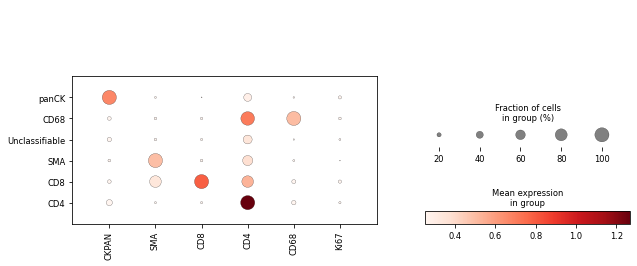

In [14]:
fig, ax = plt.subplots(figsize=(10,4))
sc.pl.dotplot(adata, var_names=adata.var_names, groupby='cell_lineage', vmin=0.25, expression_cutoff=0.25, ax=ax)

In [15]:
adata_onlytiles = adata[~adata.obs['leiden'].isna()]
adata_onlytiles = adata_onlytiles[adata_onlytiles.obs['original_set'] == 'train']

In [16]:
from scipy.stats import kurtosis

mean_ki67_df_path = os.path.join(main_path, 'data/results/ki67_intensity_by_cell_and_cluster.csv')

if os.path.exists(mean_ki67_df_path):
    mean_ki67_df = pd.read_csv(mean_ki67_df_path)
else:
    mean_ki67 = list()

    for phenotype in ['panCK', 'CD4', 'CD8', 'CD68', 'SMA', 'Unclassifiable']:
        for cluster in sorted(list(adata_onlytiles.obs['leiden'].unique())):
            mean = np.mean(adata_onlytiles.X[(adata_onlytiles.obs['cell_lineage'] == phenotype) & (adata_onlytiles.obs['leiden'] == cluster), adata_onlytiles.var_names == 'Ki67'])
            median = np.median(adata_onlytiles.X[(adata_onlytiles.obs['cell_lineage'] == phenotype) & (adata_onlytiles.obs['leiden'] == cluster), adata_onlytiles.var_names == 'Ki67'])
            std = np.std(adata_onlytiles.X[(adata_onlytiles.obs['cell_lineage'] == phenotype) & (adata_onlytiles.obs['leiden'] == cluster), adata_onlytiles.var_names == 'Ki67'])
            kurt = kurtosis(adata_onlytiles.X[(adata_onlytiles.obs['cell_lineage'] == phenotype) & (adata_onlytiles.obs['leiden'] == cluster), adata_onlytiles.var_names == 'Ki67'])
            var = np.var(adata_onlytiles.X[(adata_onlytiles.obs['cell_lineage'] == phenotype) & (adata_onlytiles.obs['leiden'] == cluster), adata_onlytiles.var_names == 'Ki67'])
            mean_ki67.append([phenotype, cluster, mean, median, std, kurt, var])

    mean_ki67_df = pd.DataFrame(mean_ki67, columns=['cell_lineage', 'leiden', 'mean', 'median', 'std', 'kurt', 'var'])
    mean_ki67_df.to_csv(mean_ki67_df_path)

mean_ki67_df

,Unnamed: 0,cell_lineage,leiden,mean,median,std,kurt,var
0,0,panCK,0,0.182592,0.069695,0.274655,5.787493,0.075435
1,1,panCK,1,0.094260,0.056690,0.154034,30.433259,0.023726
2,2,panCK,10,0.133563,0.054581,0.231832,10.543711,0.053746
3,3,panCK,11,0.315058,0.127709,0.347668,0.385095,0.120873
4,4,panCK,12,0.093820,0.048446,0.170895,26.572570,0.029205
...,...,...,...,...,...,...,...,...
163,163,Unclassifiable,5,0.088244,0.032567,0.186624,16.237614,0.034828
164,164,Unclassifiable,6,0.095231,0.052731,0.194236,40.706016,0.037727
165,165,Unclassifiable,7,0.071820,0.033903,0.158750,31.381574,0.025201
166,166,Unclassifiable,8,0.080666,0.051442,0.122763,48.307478,0.015071


#### Heatmap of ki67 by cell type

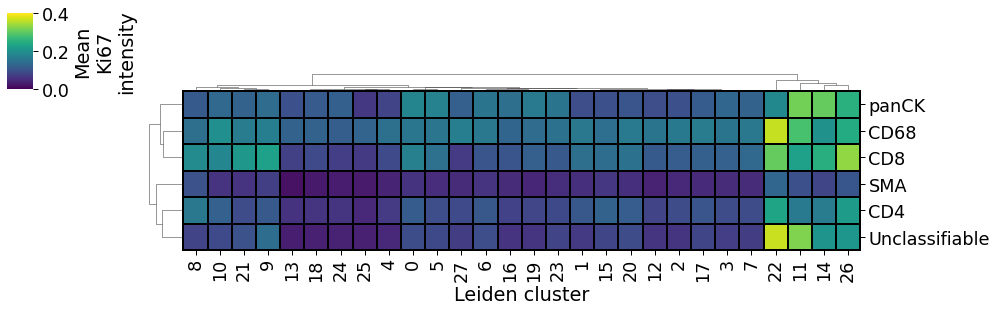

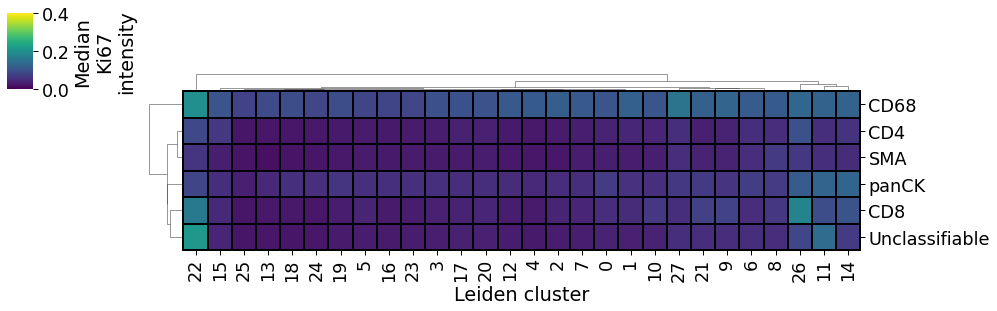

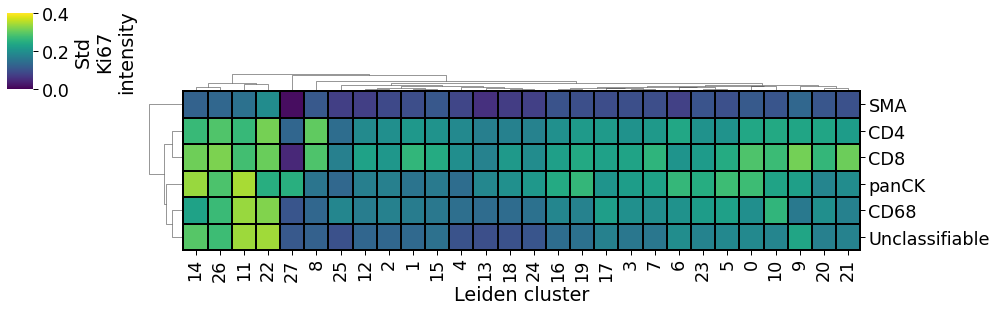

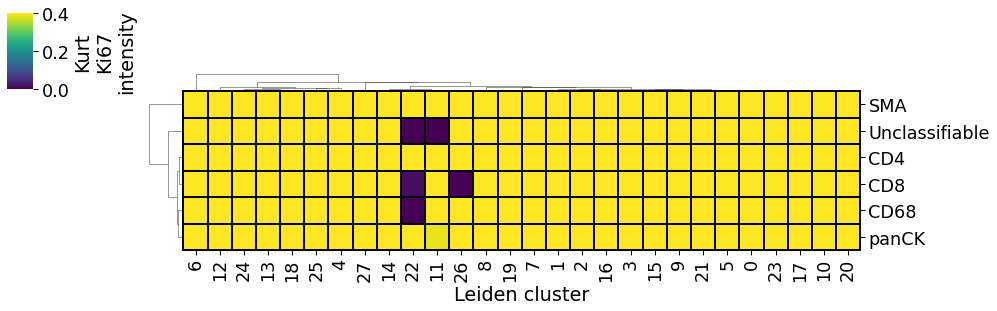

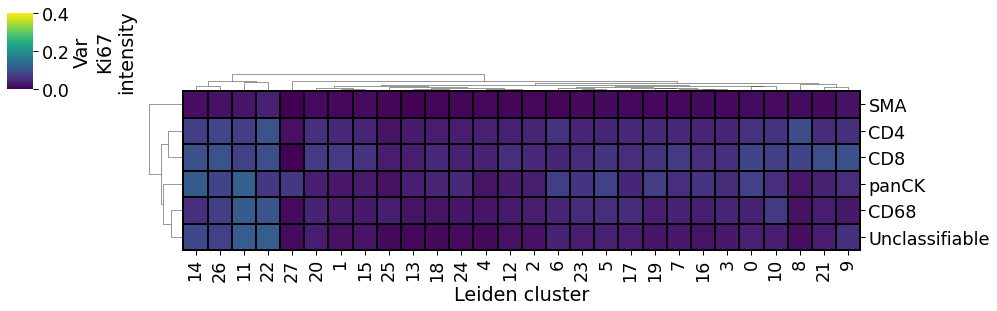

In [ ]:
metric = 'mean'

for metric in ['mean', 'median', 'std', 'kurt', 'var']:
    mean_ki67_by_cluster_celltype = mean_ki67_df[['leiden', 'cell_lineage', metric]].groupby(['leiden', 'cell_lineage']).mean().reset_index().pivot_table(values=[metric], index='leiden', columns='cell_lineage')
    mean_ki67_by_cluster_celltype.columns = [c[1] for c in mean_ki67_by_cluster_celltype.columns]
    mean_ki67_by_cluster_celltype = mean_ki67_by_cluster_celltype.T

    from matplotlib.patches import Rectangle

    g = sns.clustermap(mean_ki67_by_cluster_celltype,
                #    z_score=0,
                #    vmin=-2,
                #    vmax=100,
                cmap='viridis',
                vmin=0, vmax=0.4,
                linewidth=.01,
                dendrogram_ratio=(.05, .1),
                cbar_kws={'label':f'{metric.capitalize()}\nKi67\nintensity', 'ticks':[0, 0.2, 0.4]},
                cbar_pos=(-0.15, .895, .03, .3),
                figsize=(12,3.5))

    g.ax_heatmap.collections[0].set_edgecolor('black')
    g.ax_heatmap.collections[0].set_linewidth(.01)
    g.ax_heatmap.collections[0].colorbar.set_ticklabels([0., 0.2, 0.4])

    n_rows, n_cols = mean_ki67_by_cluster_celltype.shape

    rect = Rectangle(
        xy=(0, 0),  # Lower left corner
        width=n_cols,
        height=n_rows,
        fill=False,
        edgecolor='black',
        linewidth=2,
        clip_on=False
    )

    g.ax_heatmap.add_patch(rect);
    g.ax_heatmap.set_xlabel('Leiden cluster');
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0);
    plt.show()

### Tumour proliferation

#### Calculate cell densities

In [17]:
adata_train = adata[adata.obs['original_set'] == 'train']

In [18]:
core_areas = pd.read_csv(os.path.join(main_path, 'data/metadata/processed_core_areas.csv'), index_col=0).sort_values(by='core')

In [19]:
counts_df = pd.DataFrame()

for i, core in enumerate(adata.obs['Core_ID'].unique()):
    phenotypes, counts = np.unique(adata.obs[adata.obs['Core_ID'] == core]['cell_lineage'].values, return_counts=True)
    counts_df.loc[i, 'core'] = core
    for j, _ in enumerate(phenotypes):
        counts_df.loc[i, phenotypes[j]] = counts[j]

counts_df['lymphocyte'] = counts_df['CD4'] + counts_df['CD8']

counts_df = counts_df.fillna(0)
counts_df

,core,CD4,CD68,CD8,SMA,Unclassifiable,panCK,lymphocyte
0,22-05-J,99.0,456.0,85.0,90.0,4504.0,3327.0,184.0
1,22-10-B,3397.0,732.0,473.0,36.0,2485.0,2001.0,3870.0
2,22-04-B,365.0,899.0,410.0,705.0,4138.0,1286.0,775.0
3,22-03-B,27.0,237.0,23.0,481.0,2853.0,58.0,50.0
4,22-15-H,990.0,993.0,1663.0,340.0,4830.0,38.0,2653.0
...,...,...,...,...,...,...,...,...
2656,19-10-C,87.0,321.0,26.0,217.0,1851.0,1563.0,113.0
2657,19-03-D,1459.0,1112.0,488.0,896.0,2985.0,2176.0,1947.0
2658,19-05-J,29.0,108.0,14.0,199.0,3658.0,1079.0,43.0
2659,19-06-I,403.0,784.0,154.0,983.0,2028.0,377.0,557.0


In [20]:
counts_df['samples'] = counts_df['core'].map(bioclavis_core_dict)
counts_df = counts_df.sort_values(by='core')
counts_df = counts_df.merge(core_areas[['core', 'area_mm2']], on='core')
counts_df

,core,CD4,CD68,CD8,SMA,Unclassifiable,panCK,lymphocyte,samples,area_mm2
0,01-02-A,378.0,1076.0,154.0,407.0,4160.0,1133.0,532.0,ACA_0296,0.907125
1,01-02-B,574.0,464.0,312.0,420.0,3634.0,1340.0,886.0,ACA_0090,0.863007
2,01-02-C,332.0,520.0,75.0,566.0,2905.0,720.0,407.0,ACA_0040,0.659490
3,01-02-D,103.0,837.0,30.0,132.0,2489.0,535.0,133.0,ACA_0008,0.894065
4,01-02-F,655.0,1141.0,83.0,902.0,1820.0,1289.0,738.0,ACA_0096,0.852319
...,...,...,...,...,...,...,...,...,...,...
2655,23-15-F,64.0,117.0,25.0,354.0,2380.0,205.0,89.0,ACA_1093,0.610211
2656,23-15-G,342.0,526.0,170.0,461.0,3119.0,340.0,512.0,ACA_1099,0.954593
2657,23-15-H,280.0,450.0,292.0,468.0,5414.0,193.0,572.0,ACA_1104,0.923159
2658,23-15-I,112.0,345.0,168.0,69.0,2070.0,135.0,280.0,ACA_1108,0.548292


In [21]:
for marker in ['panCK', 'CD8', 'CD4', 'lymphocyte', 'CD68', 'SMA', 'Unclassifiable']:
    counts_df[f'{marker}_mm2'] = np.log10(counts_df[marker] / counts_df['area_mm2'] + 1)

In [22]:
counts_df = counts_df.drop(labels=['area_mm2'], axis=1)

In [23]:
core_densities_mm2 = counts_df[[col for col in counts_df if '_mm2' in col]+['samples']]
core_densities_mm2 = core_densities_mm2.groupby('samples').agg('mean').reset_index()
core_densities_mm2

,samples,panCK_mm2,CD8_mm2,CD4_mm2,lymphocyte_mm2,CD68_mm2,SMA_mm2,Unclassifiable_mm2
0,ACA_0001,2.916166,2.489061,2.539918,2.815619,3.162384,2.271970,3.469831
1,ACA_0002,2.873970,1.853810,1.828917,2.138531,2.494456,2.604583,3.495573
2,ACA_0003,2.990892,1.930438,2.779237,2.836312,3.063478,2.914573,3.489316
3,ACA_0004,2.574705,2.753720,2.996214,3.196637,3.021935,2.642544,3.591672
4,ACA_0005,3.046063,2.098293,2.662438,2.767565,2.534931,2.858000,3.319442
...,...,...,...,...,...,...,...,...
998,ACA_1109,2.604274,2.158145,2.260331,2.552835,2.721817,2.682465,3.495248
999,ACA_1110,3.372415,2.684580,2.931484,3.129347,3.027390,2.146873,3.366985
1000,ACA_1112,2.852790,2.436519,2.617207,2.871104,3.027015,2.147950,3.535762
1001,ACA_1115,3.337028,1.836721,2.331139,2.462174,2.736498,2.409898,3.567886


In [24]:
train_densities = core_densities_mm2[core_densities_mm2['samples'].isin(train_samples)]
valid_densities = core_densities_mm2[core_densities_mm2['samples'].isin(valid_samples)]

In [25]:
ki67_df = pd.DataFrame(columns=['samples', 'panCK', 'CD8', 'CD4', 'lymphocyte', 'CD68', 'SMA', 'Unclassifiable'], index=core_densities_mm2.index)
ki67_df['samples'] = core_densities_mm2['samples']
ki67_df.set_index('samples', inplace=True)

In [26]:
for sample in core_densities_mm2['samples'].unique():
    for cell_type in ki67_df.columns:
        mean_ki67 = np.mean(adata.X[(adata.obs['cell_lineage'] == cell_type) & (adata.obs['samples'] == sample), adata.var_names == 'Ki67'])
        ki67_df.loc[sample, cell_type] = mean_ki67

/mnt/cephfs/home/users/krakovic/.conda/envs/scpy/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/cephfs/home/users/krakovic/.conda/envs/scpy/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [27]:
ki67_df

,panCK,CD8,CD4,lymphocyte,CD68,SMA,Unclassifiable
samples,,,,,,,
ACA_0001,0.043965,0.07469,0.070572,NaN,0.104675,0.026756,0.044191
ACA_0002,0.143687,0.065145,0.045976,NaN,0.100094,0.039585,0.036534
ACA_0003,0.147991,0.025065,0.045972,NaN,0.119132,0.029045,0.040267
ACA_0004,0.051818,0.023828,0.025361,NaN,0.088636,0.010624,0.026104
ACA_0005,0.042719,0.009908,0.025357,NaN,0.127671,0.017237,0.017355
...,...,...,...,...,...,...,...
ACA_1109,0.166192,0.125052,0.125113,NaN,0.193283,0.049545,0.05888
ACA_1110,0.318609,0.236261,0.157008,NaN,0.219214,0.1081,0.13795
ACA_1112,0.22425,0.239738,0.168998,NaN,0.249272,0.074325,0.185423


#### Survival with continuous Ki67 measure

In [ ]:
survival, clinpath, patterns = load_clinical(main_path=main_path)

survival['Survival Status'] = survival['Survival Status'].replace({'Dead':1, 'Alive':0})
survival['Time to Survival Status (Days)'] = survival['Time to Survival Status (Days)'] / 365 * 12

survival = survival.rename(columns={'Survival Status':'os_event_ind',
                                    'Time to Survival Status (Days)':'os_event_data'})

survival_no_mucin = survival[~survival['2015 WHO Classification'].isin(['Invasive mucinous adenocarcinoma (IMA)', 'Not given'])]

/mnt/cephfs/sharedscratch/users/krakovic/MultiplexSSL/analysis/libraries/clinical.py:7: DtypeWarning: Columns (2,10,30,37,38,52,67,84,85,110,118,134,135,136,137,138,148,149,150,217,219,221,223,224,225,226,236,242,243,244,245,248,249,250,251,252,253,254,255,256,257,261,262,263,264,265,266,267,268,269,270,271,280,282,283,285,288,289,294,295,298,299,310,311,312,313,314,315,316,317,340,374,440,441,442,443,446,447,448,449,450,451,452,453,454,455,459,460,461,462,463,464,465,466,467,468,469,481,487,508,509,510,511,512,513,514,515,538,572,638,639,640,641,644,645,646,647,648,649,650,651,652,653,657,658,659,660,661,662,663,664,665,666,667,679,685,706,707,708,709,710,711,712,713,736,770,834,835,836,839,863,887) have mixed types. Specify dtype option on import or set low_memory=False.
  clinpath = pd.read_csv('/mnt/cephfs/home/users/krakovic/sharedscratch/datasets/LATTICeA/latticea_master_clinicopathological.csv')


In [30]:
ki67_df_survival = ki67_df.merge(survival_no_mucin[['samples', 'os_event_data', 'os_event_ind']], on='samples').set_index('samples')
ki67_df_survival = ki67_df_survival[~ki67_df_survival['os_event_data'].isna()]
ki67_df_survival = ki67_df_survival[~ki67_df_survival['os_event_ind'].isna()]
ki67_df_survival

,panCK,CD8,CD4,lymphocyte,CD68,SMA,Unclassifiable,os_event_data,os_event_ind
samples,,,,,,,,,
ACA_0002,0.143687,0.065145,0.045976,NaN,0.100094,0.039585,0.036534,18.739726,0
ACA_0003,0.147991,0.025065,0.045972,NaN,0.119132,0.029045,0.040267,57.304110,1
ACA_0004,0.051818,0.023828,0.025361,NaN,0.088636,0.010624,0.026104,35.178082,1
ACA_0005,0.042719,0.009908,0.025357,NaN,0.127671,0.017237,0.017355,61.315068,0
ACA_0006,0.302383,0.205598,0.169502,NaN,0.178575,0.09623,0.134279,0.558904,1
...,...,...,...,...,...,...,...,...,...
ACA_1108,0.07396,0.041399,0.064631,NaN,0.113436,0.040204,0.05061,31.791781,0
ACA_1109,0.166192,0.125052,0.125113,NaN,0.193283,0.049545,0.05888,20.712329,1
ACA_1110,0.318609,0.236261,0.157008,NaN,0.219214,0.1081,0.13795,21.994521,1


In [31]:
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

# Is measuring Ki67 by mean intensity valid? We would expect a poor prognosis associated with CK Ki67+
# We see this, so using Ki67 as a continuous metric rather than % positivity is probably OK

cph = CoxPHFitter(penalizer=0.01)

cph.fit(ki67_df_survival.drop(labels=['lymphocyte', 'Unclassifiable'], axis=1).dropna(), duration_col='os_event_data', event_col='os_event_ind')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 922 total observations, 280 right-censored observations>
             duration col = 'os_event_data'
                event col = 'os_event_ind'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 922
number of events observed = 642
   partial log-likelihood = -3887.57
         time fit was run = 2025-10-13 15:27:34 UTC

---
            coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                         
panCK       1.47       4.35       0.50             0.48             2.46                 1.62                11.69
CD8        -0.39       0.68       0.79            -1.94             1.17                 0.14                 3.21
CD4         1.99       7.34       1.34            -0.62             4.61                 0.54               100.53
CD68        0.19       1.21       1.06            -1.89             2.27                 0.15                 9.73
SMA        -1.92       0.15       2.06            -5.97             2.13                 0.00                 8.37

            cmp to     z      p   -log2(p)
covariate                                 
panCK         0.00  2.92 <0.005       8.15
CD8           0.00 -0.49   0.62       0.68
CD4           0.00  1.49   0.14       2.88
CD68          0.00  0.18   0.86       0.22
SMA           0.00 -0.93   0.35       1.51
---
Concordance = 0.57
Partial AIC = 7785.15
log-likelihood ratio test = 17.58 on 5 df
-log2(p) of ll-ratio test = 8.15

Text(0.5, 1.0, 'Mean cell Ki67 intensity by phenotype')

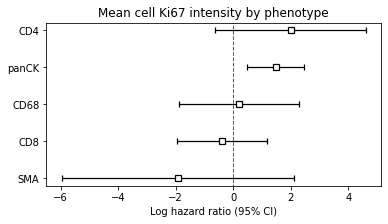

In [32]:
fig, ax = plt.subplots(figsize=(6,3))

cph.plot(ax=ax)
ax.set_xlabel('Log hazard ratio (95% CI)')
ax.set_title('Mean cell Ki67 intensity by phenotype')

#### Split measures by median

In [33]:
median_ck_ki67 = np.median(ki67_df['panCK'].values)
median_ck_ki67

0.11307293523605093

In [34]:
ki67_df['panck_ki67_high'] = ki67_df['panCK'].apply(lambda x: 1 if x > median_ck_ki67 else 0)

In [35]:
median_lym = np.median(core_densities_mm2['lymphocyte_mm2'].values)
median_cd4 = np.median(core_densities_mm2['CD4_mm2'].values)
median_cd8 = np.median(core_densities_mm2['CD8_mm2'].values)

core_densities_mm2['lym_high'] = core_densities_mm2['lymphocyte_mm2'].apply(lambda x: 1 if x > median_lym else 0)
core_densities_mm2['cd4_high'] = core_densities_mm2['CD4_mm2'].apply(lambda x: 1 if x > median_cd4 else 0)
core_densities_mm2['cd8_high'] = core_densities_mm2['CD8_mm2'].apply(lambda x: 1 if x > median_cd8 else 0)

core_densities_mm2

,samples,panCK_mm2,CD8_mm2,CD4_mm2,lymphocyte_mm2,CD68_mm2,SMA_mm2,Unclassifiable_mm2,lym_high,cd4_high,cd8_high
0,ACA_0001,2.916166,2.489061,2.539918,2.815619,3.162384,2.271970,3.469831,1,1,1
1,ACA_0002,2.873970,1.853810,1.828917,2.138531,2.494456,2.604583,3.495573,0,0,0
2,ACA_0003,2.990892,1.930438,2.779237,2.836312,3.063478,2.914573,3.489316,1,1,0
3,ACA_0004,2.574705,2.753720,2.996214,3.196637,3.021935,2.642544,3.591672,1,1,1
4,ACA_0005,3.046063,2.098293,2.662438,2.767565,2.534931,2.858000,3.319442,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
998,ACA_1109,2.604274,2.158145,2.260331,2.552835,2.721817,2.682465,3.495248,0,0,0
999,ACA_1110,3.372415,2.684580,2.931484,3.129347,3.027390,2.146873,3.366985,1,1,1
1000,ACA_1112,2.852790,2.436519,2.617207,2.871104,3.027015,2.147950,3.535762,1,1,1
1001,ACA_1115,3.337028,1.836721,2.331139,2.462174,2.736498,2.409898,3.567886,0,0,0


In [36]:
num_samples = core_densities_mm2.shape[0]
num_train = train_samples.shape[0]
num_valid = valid_samples.shape[0]

train_lym_high = core_densities_mm2[core_densities_mm2['samples'].isin(train_samples)]['lym_high'].value_counts()[1]
valid_lym_high = core_densities_mm2[core_densities_mm2['samples'].isin(valid_samples)]['lym_high'].value_counts()[1]

train_cd4_high = core_densities_mm2[core_densities_mm2['samples'].isin(train_samples)]['cd4_high'].value_counts()[1]
valid_cd4_high = core_densities_mm2[core_densities_mm2['samples'].isin(valid_samples)]['cd4_high'].value_counts()[1]

train_cd8_high = core_densities_mm2[core_densities_mm2['samples'].isin(train_samples)]['cd8_high'].value_counts()[1]
valid_cd8_high = core_densities_mm2[core_densities_mm2['samples'].isin(valid_samples)]['cd8_high'].value_counts()[1]

train_ki67_high = ki67_df[ki67_df.index.isin(train_samples)]['panck_ki67_high'].value_counts()[1]
valid_ki67_high = ki67_df[ki67_df.index.isin(valid_samples)]['panck_ki67_high'].value_counts()[1]

print(f'Lymphocyte high\n\tTrain/test: {train_lym_high / num_train:.3f}/{valid_lym_high / num_valid:.3f}')
print(f'CD4 high\n\tTrain/test: {train_cd4_high / num_train:.3f}/{valid_cd4_high / num_valid:.3f}')
print(f'CD8 high\n\tTrain/test: {train_cd8_high / num_train:.3f}/{valid_cd8_high / num_valid:.3f}')
print(f'Ki67 high\n\tTrain/test: {train_ki67_high / num_train:.3f}/{valid_ki67_high / num_valid:.3f}')

Lymphocyte high
	Train/test: 0.492/0.508
CD4 high
	Train/test: 0.486/0.514
CD8 high
	Train/test: 0.492/0.506
Ki67 high
	Train/test: 0.512/0.484


In [37]:
combined_highlow = core_densities_mm2[['samples', 'lym_high', 'cd4_high', 'cd8_high']].merge(ki67_df.reset_index(names='samples')[['samples', 'panck_ki67_high']])
combined_highlow

,samples,lym_high,cd4_high,cd8_high,panck_ki67_high
0,ACA_0001,1,1,1,0
1,ACA_0002,0,0,0,1
2,ACA_0003,1,1,0,1
3,ACA_0004,1,1,1,0
4,ACA_0005,1,1,0,0
...,...,...,...,...,...
998,ACA_1109,0,0,0,1
999,ACA_1110,1,1,1,1
1000,ACA_1112,1,1,1,1
1001,ACA_1115,0,0,0,0


In [38]:
combined_highlow_survival = combined_highlow.merge(survival_no_mucin[['samples', 'os_event_data', 'os_event_ind']], on='samples').set_index('samples')
combined_highlow_survival

,lym_high,cd4_high,cd8_high,panck_ki67_high,os_event_data,os_event_ind
samples,,,,,,
ACA_0002,0,0,0,1,18.739726,0
ACA_0003,1,1,0,1,57.304110,1
ACA_0004,1,1,1,0,35.178082,1
ACA_0005,1,1,0,0,61.315068,0
ACA_0006,0,0,1,1,0.558904,1
...,...,...,...,...,...,...
ACA_1108,1,0,1,0,31.791781,0
ACA_1109,0,0,0,1,20.712329,1
ACA_1110,1,1,1,1,21.994521,1


#### Survival with dichotomised Ki67 and density

In [39]:
cph = CoxPHFitter()

# Dichotomised measures are still prognostic, independently (Ki67 with one of the immune measures)
# Multiple immune measures cancel out though, not unexpected

cph.fit(combined_highlow_survival[['panck_ki67_high', 'lym_high', 'os_event_data', 'os_event_ind']].dropna(), duration_col='os_event_data', event_col='os_event_ind')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 923 total observations, 281 right-censored observations>
             duration col = 'os_event_data'
                event col = 'os_event_ind'
      baseline estimation = breslow
   number of observations = 923
number of events observed = 642
   partial log-likelihood = -3882.34
         time fit was run = 2025-10-13 15:27:56 UTC

---
                  coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                               
panck_ki67_high   0.38       1.46       0.08             0.23             0.54                 1.25                 1.71
lym_high         -0.20       0.81       0.08            -0.36            -0.05                 0.70                 0.95

                  cmp to     z      p   -log2(p)
covariate                                       
panck_ki67_high     0.00  4.79 <0.005      19.17
lym_high            0.00 -2.59   0.01       6.69
---
Concordance = 0.57
Partial AIC = 7768.68
log-likelihood ratio test = 29.86 on 2 df
-log2(p) of ll-ratio test = 21.54

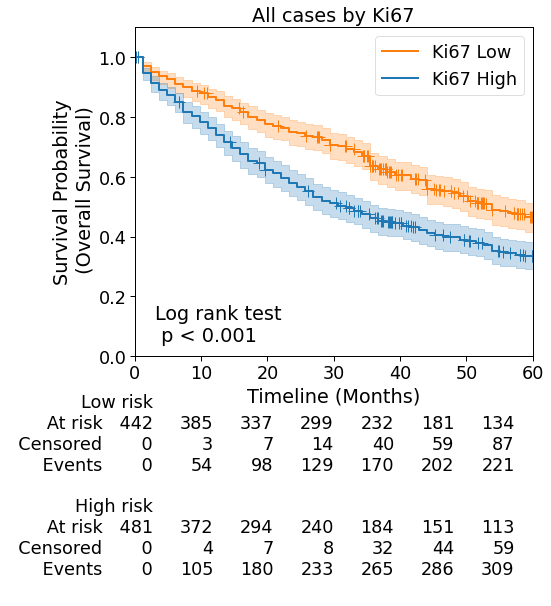

In [40]:
from analysis.libraries.survival import plot_km_two_groups

sns.set_context("paper", font_scale=2.0)
fig, ax = plt.subplots(figsize=(8,9))

plot_km_two_groups(df=combined_highlow_survival.dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='panck_ki67_high', 
                   max_months=60, 
                   add_counts=True, 
                   title='All cases by Ki67', 
                   ci_show=True, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [f'Ki67 Low', f'Ki67 High'])  

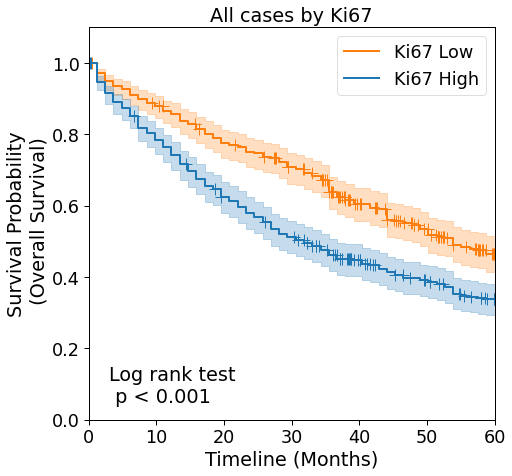

In [41]:
fig, ax = plt.subplots(figsize=(7.5,7))

plot_km_two_groups(df=combined_highlow_survival.dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='panck_ki67_high', 
                   max_months=60, 
                   add_counts=False, 
                   title='All cases by Ki67', 
                   ci_show=True, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [f'Ki67 Low', f'Ki67 High'])  

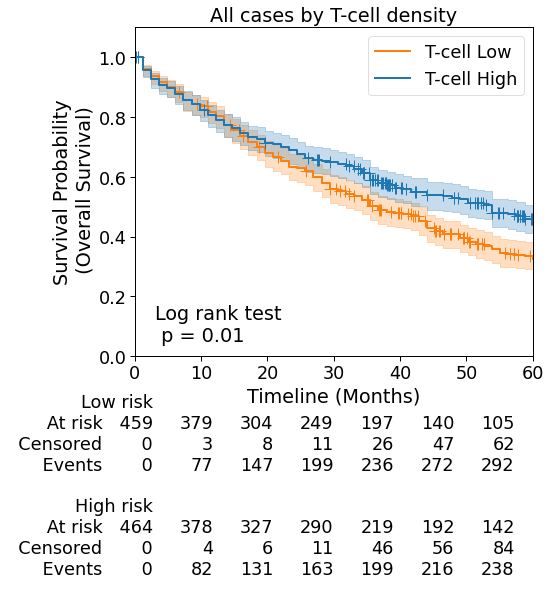

In [42]:
sns.set_context("paper", font_scale=2.0)
fig, ax = plt.subplots(figsize=(8,9))

plot_km_two_groups(df=combined_highlow_survival.dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='lym_high', 
                   max_months=60, 
                   add_counts=True, 
                   title='All cases by T-cell density', 
                   ci_show=True, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [f'T-cell Low', f'T-cell High'])  

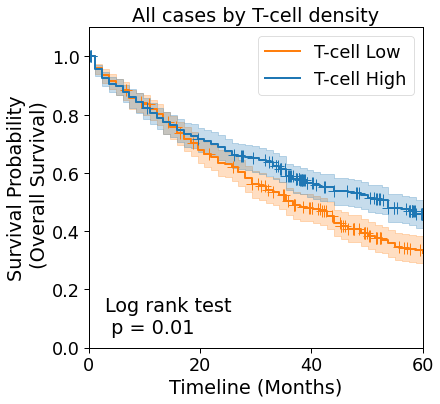

In [43]:
sns.set_context("paper", font_scale=2.0)
fig, ax = plt.subplots(figsize=(6.5,6))

plot_km_two_groups(df=combined_highlow_survival.dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='lym_high', 
                   max_months=60, 
                   add_counts=False, 
                   title='All cases by T-cell density', 
                   ci_show=True, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [f'T-cell Low', f'T-cell High'])  

##### Lymphocyte density by Ki67 status 

In [44]:
ki67_high = combined_highlow_survival[combined_highlow_survival['panck_ki67_high'] == 1]

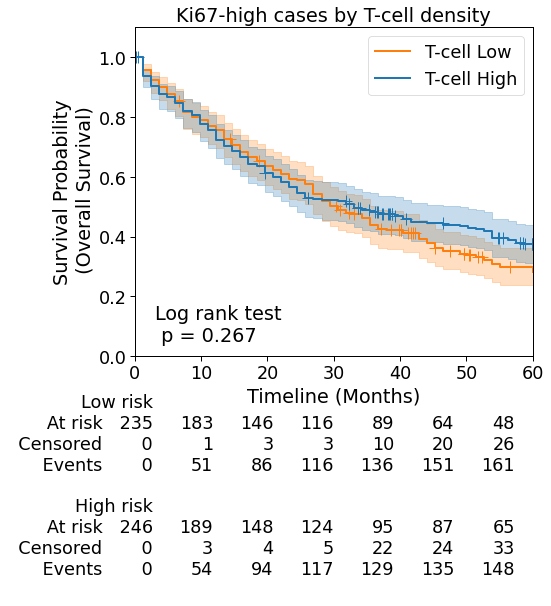

In [45]:
sns.set_context("paper", font_scale=2.0)
fig, ax = plt.subplots(figsize=(8,9))

plot_km_two_groups(df=ki67_high.dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='lym_high', 
                   max_months=60, 
                   add_counts=True, 
                   title='Ki67-high cases by T-cell density', 
                   ci_show=True, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [f'T-cell Low', f'T-cell High'])  

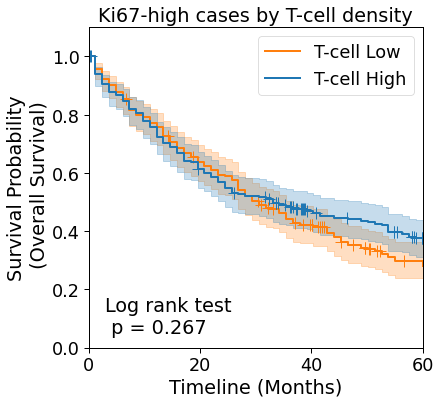

In [46]:
sns.set_context("paper", font_scale=2.0)
fig, ax = plt.subplots(figsize=(6.5,6))

plot_km_two_groups(df=ki67_high.dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='lym_high', 
                   max_months=60, 
                   add_counts=False, 
                   title='Ki67-high cases by T-cell density', 
                   ci_show=True, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [f'T-cell Low', f'T-cell High'])  

In [47]:
combined_highlow_survival

,lym_high,cd4_high,cd8_high,panck_ki67_high,os_event_data,os_event_ind
samples,,,,,,
ACA_0002,0,0,0,1,18.739726,0
ACA_0003,1,1,0,1,57.304110,1
ACA_0004,1,1,1,0,35.178082,1
ACA_0005,1,1,0,0,61.315068,0
ACA_0006,0,0,1,1,0.558904,1
...,...,...,...,...,...,...
ACA_1108,1,0,1,0,31.791781,0
ACA_1109,0,0,0,1,20.712329,1
ACA_1110,1,1,1,1,21.994521,1


###### PD-L1 status and Ki67  

In [48]:
### Side thought -- is this group enriched for PD-L1 positivity?
### As categorical variables -- chi-squared test
from scipy.stats import chi2_contingency

ki67_pdl1 = combined_highlow_survival[['lym_high', 'panck_ki67_high']].reset_index().merge(clinpath_mo[['samples', 'PDL_positive']], on='samples', how='inner').dropna()
cont_table = pd.crosstab(ki67_pdl1['panck_ki67_high'], ki67_pdl1['PDL_positive'])
chi2, p_chi2, dof, expected = chi2_contingency(cont_table)

print("Chi-square test:")
print(f"Chi2 statistic = {chi2:.4f}, p-value = {p_chi2:.4f}")

Chi-square test:
Chi2 statistic = 24.1820, p-value = 0.0000


In [49]:
cont_table

PDL_positive,0.0,1.0
panck_ki67_high,,
0,281,52
1,276,127


In [50]:
ki67_df_pdl1 = ki67_df[['panCK', 'panck_ki67_high']].reset_index().merge(clinpath_mo[['samples', 'PDL_positive']], on='samples', how='inner').dropna()
ki67_df_pdl1['panCK'] = ki67_df_pdl1['panCK'].astype(float)
ki67_df_pdl1

,samples,panCK,panck_ki67_high,PDL_positive
1,ACA_0003,0.147991,1,0.0
2,ACA_0004,0.051818,0,0.0
3,ACA_0005,0.042719,0,0.0
4,ACA_0006,0.302383,1,0.0
6,ACA_0008,0.286918,1,0.0
...,...,...,...,...
908,ACA_1108,0.073960,0,0.0
909,ACA_1109,0.166192,1,0.0
910,ACA_1110,0.318609,1,1.0
911,ACA_1112,0.224250,1,0.0


In [52]:
combined_highlow_survival

,lym_high,cd4_high,cd8_high,panck_ki67_high,os_event_data,os_event_ind
samples,,,,,,
ACA_0002,0,0,0,1,18.739726,0
ACA_0003,1,1,0,1,57.304110,1
ACA_0004,1,1,1,0,35.178082,1
ACA_0005,1,1,0,0,61.315068,0
ACA_0006,0,0,1,1,0.558904,1
...,...,...,...,...,...,...
ACA_1108,1,0,1,0,31.791781,0
ACA_1109,0,0,0,1,20.712329,1
ACA_1110,1,1,1,1,21.994521,1


In [53]:
ki67_df_pdl1_combined = ki67_df_pdl1.merge(combined_highlow_survival.reset_index(), on='samples', how='inner')
ki67_df_pdl1_combined

,samples,panCK,panck_ki67_high_x,PDL_positive,lym_high,cd4_high,cd8_high,panck_ki67_high_y,os_event_data,os_event_ind
0,ACA_0003,0.147991,1,0.0,1,1,0,1,57.304110,1
1,ACA_0004,0.051818,0,0.0,1,1,1,0,35.178082,1
2,ACA_0005,0.042719,0,0.0,1,1,0,0,61.315068,0
3,ACA_0006,0.302383,1,0.0,0,0,1,1,0.558904,1
4,ACA_0008,0.286918,1,0.0,0,0,0,1,14.268493,1
...,...,...,...,...,...,...,...,...,...,...
731,ACA_1108,0.073960,0,0.0,1,0,1,0,31.791781,0
732,ACA_1109,0.166192,1,0.0,0,0,0,1,20.712329,1
733,ACA_1110,0.318609,1,1.0,1,1,1,1,21.994521,1
734,ACA_1112,0.224250,1,0.0,1,1,1,1,24.427397,1


In [55]:
ki67_df_pdl1_combined.to_csv(os.path.join(main_path, 'data/results/ki67_pdl1_df.csv'))

/tmp/ipykernel_3762633/3852877508.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Negative', 'Positive'])


[Text(0, 0, 'Negative'), Text(1, 0, 'Positive')]

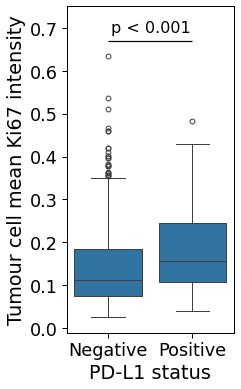

In [54]:
from scipy import stats

fig, ax = plt.subplots(figsize=(3,6))
sns.boxplot(ki67_df_pdl1, x='PDL_positive', y='panCK', ax=ax)

stat, p_val = stats.mannwhitneyu(ki67_df_pdl1[ki67_df_pdl1['PDL_positive'] == 1]['panCK'].values, ki67_df_pdl1[ki67_df_pdl1['PDL_positive'] == 0]['panCK'].values, alternative='two-sided')
ax.set_ylim([-0.01, 0.75])
ax.hlines(xmin=0, xmax=1, y=0.67, color='black')
ax.text(s=f'p < 0.001', x=0.04, y=0.69, fontsize=16)
ax.set_ylabel('Tumour cell mean Ki67 intensity')
ax.set_xlabel('PD-L1 status')
ax.set_xticklabels(['Negative', 'Positive'])

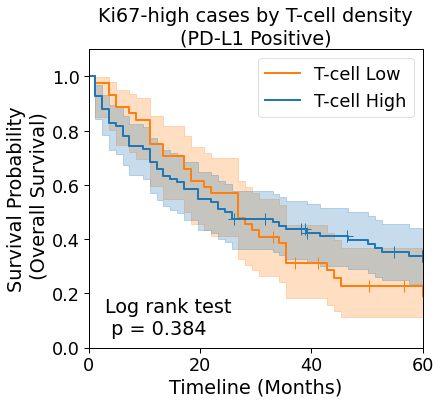

In [56]:
sns.set_context("paper", font_scale=2.0)
pdl1_pos_cases = ki67_df_pdl1[ki67_df_pdl1['PDL_positive'] == 1]['samples']

fig, ax = plt.subplots(figsize=(6.5,6))

plot_km_two_groups(df=ki67_high[ki67_high.index.isin(pdl1_pos_cases)].dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='lym_high', 
                   max_months=60, 
                   add_counts=False, 
                   title='Ki67-high cases by T-cell density\n(PD-L1 Positive)', 
                   ci_show=True, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [f'T-cell Low', f'T-cell High'])  

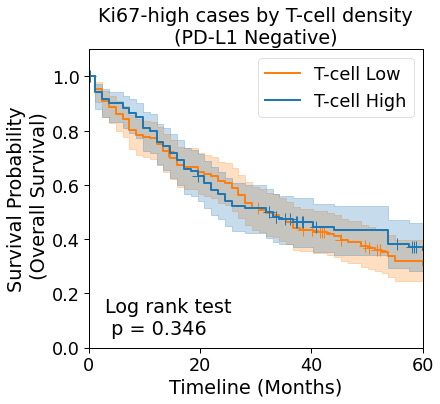

In [57]:
sns.set_context("paper", font_scale=2.0)
pdl1_neg_cases = ki67_df_pdl1[ki67_df_pdl1['PDL_positive'] == 0]['samples']

fig, ax = plt.subplots(figsize=(6.5,6))

plot_km_two_groups(df=ki67_high[ki67_high.index.isin(pdl1_neg_cases)].dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='lym_high', 
                   max_months=60, 
                   add_counts=False, 
                   title='Ki67-high cases by T-cell density\n(PD-L1 Negative)', 
                   ci_show=True, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [f'T-cell Low', f'T-cell High'])  

In [58]:
ki67_high[ki67_high.index.isin(pdl1_pos_cases)].dropna()['lym_high'].value_counts()

1    82
0    44
Name: lym_high, dtype: int64

In [59]:
ki67_high[ki67_high.index.isin(pdl1_neg_cases)].dropna()['lym_high'].value_counts()


0    153
1    122
Name: lym_high, dtype: int64

In [60]:
ki67_low = combined_highlow_survival[combined_highlow_survival['panck_ki67_high'] == 0]

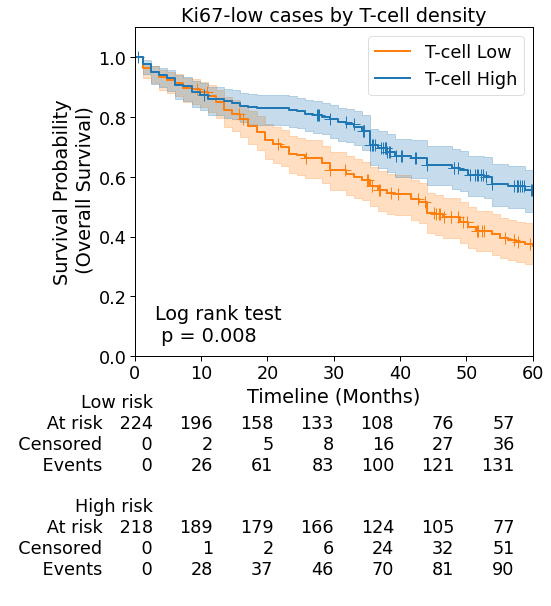

In [61]:
sns.set_context("paper", font_scale=2.0)
fig, ax = plt.subplots(figsize=(8,9))

plot_km_two_groups(df=ki67_low.dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='lym_high', 
                   max_months=60, 
                   add_counts=True, 
                   title='Ki67-low cases by T-cell density', 
                   ci_show=True, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [f'T-cell Low', f'T-cell High'])  

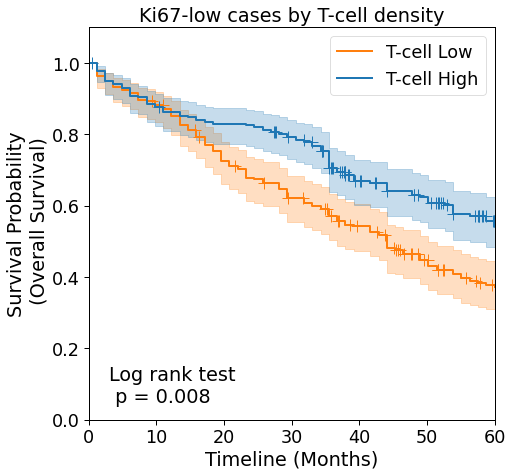

In [62]:
sns.set_context("paper", font_scale=2.0)
fig, ax = plt.subplots(figsize=(7.5,7))

plot_km_two_groups(df=ki67_low.dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='lym_high', 
                   max_months=60, 
                   add_counts=False, 
                   title='Ki67-low cases by T-cell density', 
                   ci_show=True, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [f'T-cell Low', f'T-cell High'])  

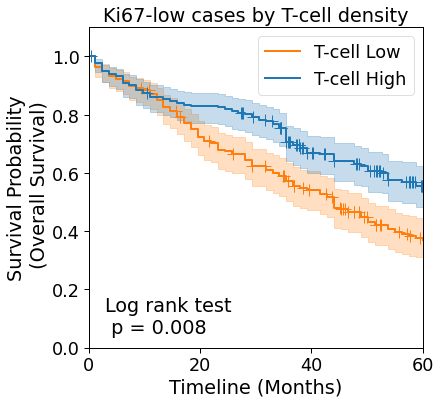

In [63]:
sns.set_context("paper", font_scale=2.0)
fig, ax = plt.subplots(figsize=(6.5,6))

plot_km_two_groups(df=ki67_low.dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='lym_high', 
                   max_months=60, 
                   add_counts=False, 
                   title='Ki67-low cases by T-cell density', 
                   ci_show=True, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [f'T-cell Low', f'T-cell High'])  

##### Ki67 status by lymphocyte density

In [64]:
lym_high = combined_highlow_survival[combined_highlow_survival['lym_high'] == 1]

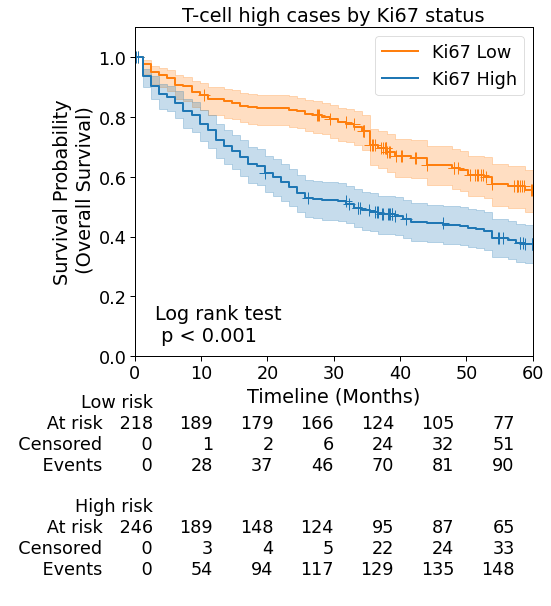

In [65]:
sns.set_context("paper", font_scale=2.0)
fig, ax = plt.subplots(figsize=(8,9))

plot_km_two_groups(df=lym_high.dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='panck_ki67_high', 
                   max_months=60, 
                   add_counts=True, 
                   title='T-cell high cases by Ki67 status', 
                   ci_show=True, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Ki67 Low', 'Ki67 High'])  

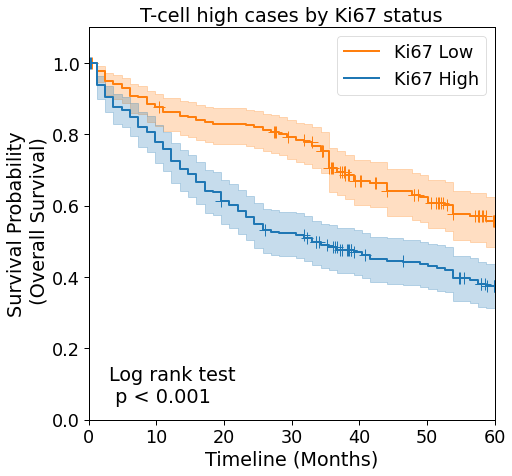

In [66]:
sns.set_context("paper", font_scale=2.0)
fig, ax = plt.subplots(figsize=(7.5,7))

plot_km_two_groups(df=lym_high.dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='panck_ki67_high', 
                   max_months=60, 
                   add_counts=False, 
                   title='T-cell high cases by Ki67 status', 
                   ci_show=True, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Ki67 Low', 'Ki67 High'])  

In [67]:
lym_low = combined_highlow_survival[combined_highlow_survival['lym_high'] == 0]

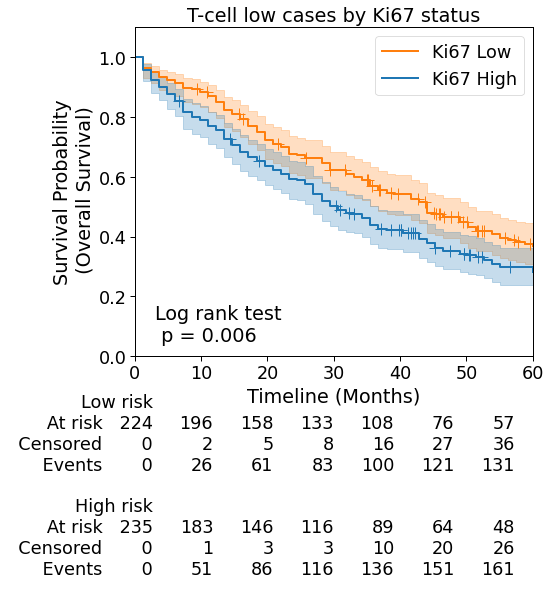

In [68]:
sns.set_context("paper", font_scale=2.0)
fig, ax = plt.subplots(figsize=(8,9))

plot_km_two_groups(df=lym_low.dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='panck_ki67_high', 
                   max_months=60, 
                   add_counts=True, 
                   title='T-cell low cases by Ki67 status', 
                   ci_show=True, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Ki67 Low', 'Ki67 High'])  

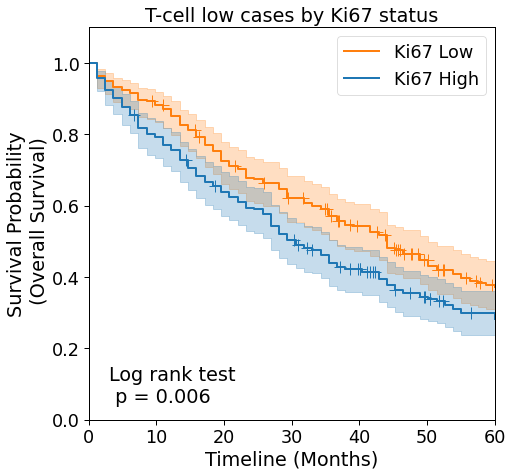

In [69]:
sns.set_context("paper", font_scale=2.0)
fig, ax = plt.subplots(figsize=(7.5,7))

plot_km_two_groups(df=lym_low.dropna(), 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='panck_ki67_high', 
                   max_months=60, 
                   add_counts=False, 
                   title='T-cell low cases by Ki67 status', 
                   ci_show=True, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Ki67 Low', 'Ki67 High'])  

##### Assign all cases to one of four groups high/low

In [70]:
def classify_lym_density_and_ki67(row):
    if row['panck_ki67_high'] == 1 and row['lym_high'] == 1:
        return 'ki67_high_lym_high'
    elif row['panck_ki67_high'] == 0 and row['lym_high'] == 1:
        return 'ki67_low_lym_high'
    elif row['panck_ki67_high'] == 1 and row['lym_high'] == 0:
        return 'ki67_high_lym_low'
    elif row['panck_ki67_high'] == 0 and row['lym_high'] == 0:
        return 'ki67_low_lym_low'
    else:
        return 'Unknown'
    
combined_highlow_survival['ki67_lym_class'] = combined_highlow_survival.apply(lambda row: classify_lym_density_and_ki67(row), axis=1)


In [71]:
combined_highlow_survival_ = pd.get_dummies(combined_highlow_survival)
combined_highlow_survival_

,lym_high,cd4_high,cd8_high,panck_ki67_high,os_event_data,os_event_ind,ki67_lym_class_ki67_high_lym_high,ki67_lym_class_ki67_high_lym_low,ki67_lym_class_ki67_low_lym_high,ki67_lym_class_ki67_low_lym_low
samples,,,,,,,,,,
ACA_0002,0,0,0,1,18.739726,0,0,1,0,0
ACA_0003,1,1,0,1,57.304110,1,1,0,0,0
ACA_0004,1,1,1,0,35.178082,1,0,0,1,0
ACA_0005,1,1,0,0,61.315068,0,0,0,1,0
ACA_0006,0,0,1,1,0.558904,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
ACA_1108,1,0,1,0,31.791781,0,0,0,1,0
ACA_1109,0,0,0,1,20.712329,1,0,1,0,0
ACA_1110,1,1,1,1,21.994521,1,1,0,0,0


In [72]:
cph = CoxPHFitter()

cph.fit(combined_highlow_survival_[['ki67_lym_class_ki67_high_lym_high', 'ki67_lym_class_ki67_high_lym_low', 'ki67_lym_class_ki67_low_lym_low',
                                   'os_event_data', 'os_event_ind']].dropna(), duration_col='os_event_data', event_col='os_event_ind')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 923 total observations, 281 right-censored observations>
             duration col = 'os_event_data'
                event col = 'os_event_ind'
      baseline estimation = breslow
   number of observations = 923
number of events observed = 642
   partial log-likelihood = -3881.72
         time fit was run = 2025-10-13 15:33:55 UTC

---
                                    coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                                                 
ki67_lym_class_ki67_high_lym_high   0.48       1.61       0.12             0.25             0.71                 1.28                 2.02
ki67_lym_class_ki67_high_lym_low    0.60       1.83       0.12             0.38             0.83                 1.46                 2.30
ki67_lym_class_ki67_low_lym_low     0.31       1.36       0.12             0.07             0.54                 1.07                 1.72

                                    cmp to    z      p   -log2(p)
covariate                                                        
ki67_lym_class_ki67_high_lym_high     0.00 4.07 <0.005      14.41
ki67_lym_class_ki67_high_lym_low      0.00 5.20 <0.005      22.29
ki67_lym_class_ki67_low_lym_low       0.00 2.54   0.01       6.48
---
Concordance = 0.57
Partial AIC = 7769.44
log-likelihood ratio test = 31.10 on 3 df
-log2(p) of ll-ratio test = 20.24

<Axes: xlabel='log(HR) (95% CI)'>

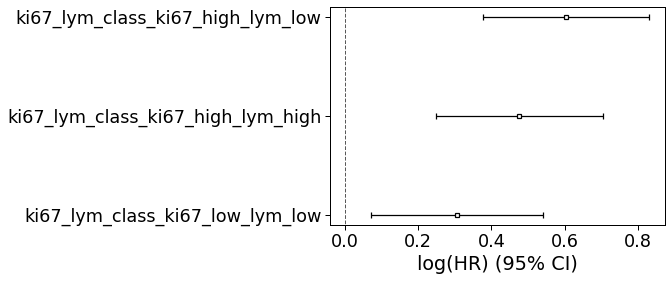

In [73]:
cph.plot()

In [76]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

def plot_km_multiple_groups(df, event_ind_field, event_data_field, group_col, max_months, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    time = np.linspace(0, max_months)
    colors = plt.cm.tab10.colors  # Use a color cycle for multiple groups
    
    groups = df[group_col].unique()
    kmf_dict = {}
    
    for i, group in enumerate(groups):
        kmf = KaplanMeierFitter(label=f'{group}')
        mask = df[group_col] == group
        kmf.fit(df[mask][event_data_field], df[mask][event_ind_field], timeline=time)
        kmf.plot_survival_function(show_censors=True, ci_show=True, ax=ax, lw=2, color=colors[i])
        kmf_dict[group] = kmf
    
    # Perform multivariate logrank test
    result = multivariate_logrank_test(df[event_data_field], df[group_col], df[event_ind_field])
    p_val = np.round(result.p_value, 3)
    if p_val < 0.001:
        p_val = '< 0.001'
    
    ax.set_title(f'{title}')
    ax.text(x=5, y=0.05, s=f'Multivariate log rank test \np {p_val}')
    ax.set_ylim([0.1, 1.10])
    ax.set_ylabel('Survival Probability\n (Overall Survival)')
    ax.set_xlabel('Timeline (Months)')
    ax.set_xticks(ticks=ax.get_xticks())
    ax.set_yticks(ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.legend()
    
    if max_months is None:
        max_months = df[event_data_field].max() + 6
    ax.set_xlim([0.0, max_months])
    
    plt.tight_layout()
    
    return ax

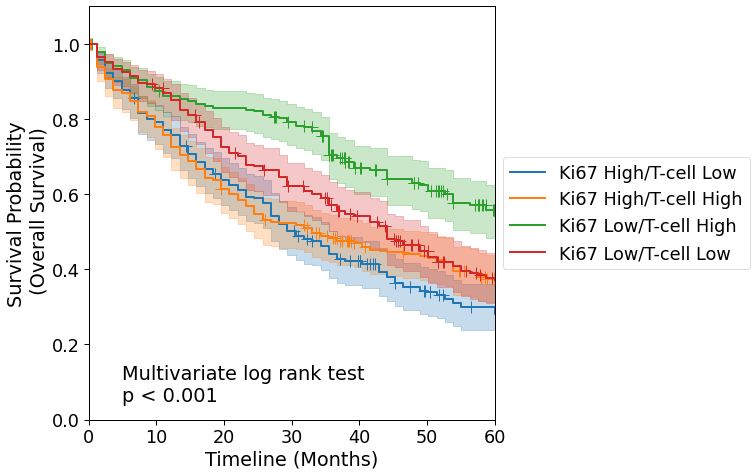

In [77]:
fig, ax = plt.subplots(figsize=(7.5,7))

plot_km_multiple_groups(df=combined_highlow_survival.dropna(), 
                        event_ind_field='os_event_ind', 
                        event_data_field='os_event_data', 
                        group_col='ki67_lym_class', 
                        max_months=60, 
                        title="", 
                        ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Ki67 High/T-cell Low', 'Ki67 High/T-cell High', 'Ki67 Low/T-cell High', 'Ki67 Low/T-cell Low'])  
sns.move_legend(ax, loc='right', bbox_to_anchor=(1.65, 0.5), )

In [78]:
combined_highlow_survival.dropna()['ki67_lym_class'].value_counts()

ki67_high_lym_high    246
ki67_high_lym_low     235
ki67_low_lym_low      224
ki67_low_lym_high     218
Name: ki67_lym_class, dtype: int64

<Axes: title={'center': 'Test'}, xlabel='Timeline (Months)', ylabel='Survival Probability\n (Overall Survival)'>

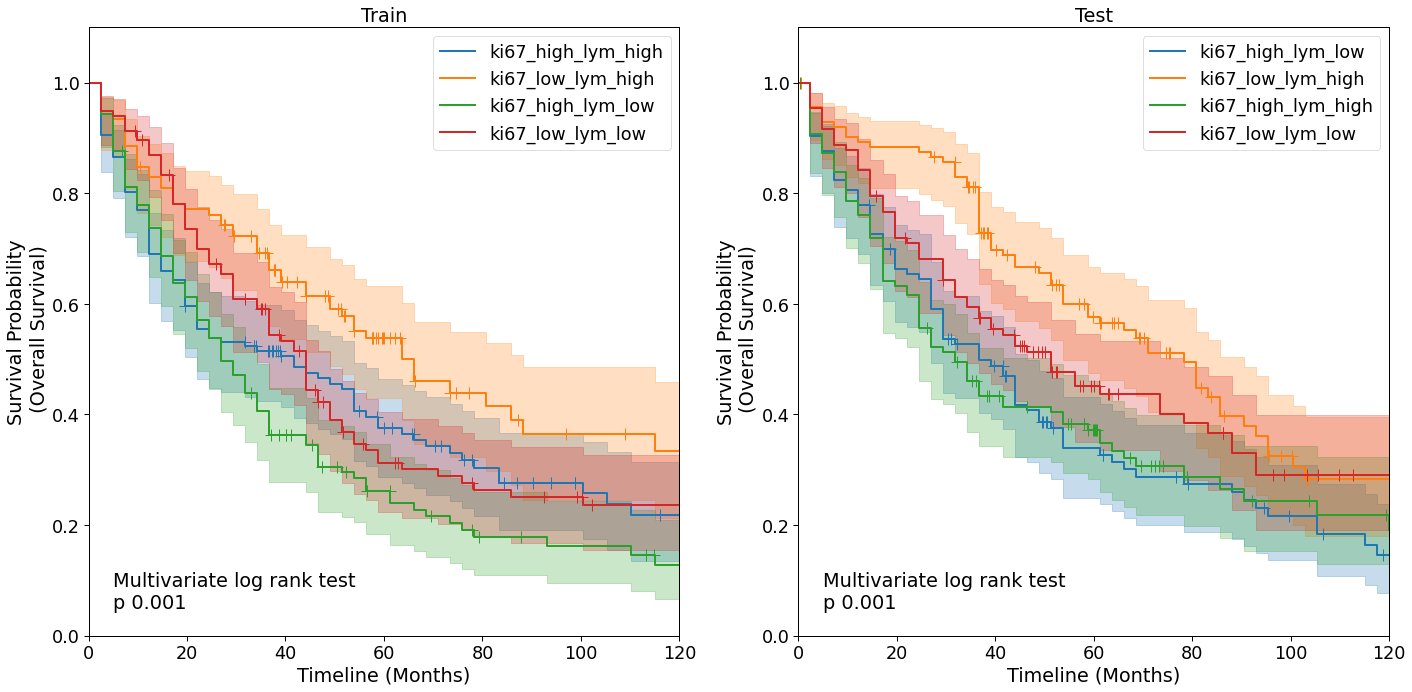

In [79]:
train_combined = combined_highlow_survival[combined_highlow_survival.index.isin(train_samples)]
valid_combined = combined_highlow_survival[combined_highlow_survival.index.isin(valid_samples)]

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20,10))
axs = axs.flatten()

plot_km_multiple_groups(df=train_combined.dropna(), 
                        event_ind_field='os_event_ind', 
                        event_data_field='os_event_data', 
                        group_col='ki67_lym_class', 
                        max_months=120, 
                        title='Train', 
                        ax=axs[0])

plot_km_multiple_groups(df=valid_combined.dropna(), 
                        event_ind_field='os_event_ind', 
                        event_data_field='os_event_data', 
                        group_col='ki67_lym_class', 
                        max_months=120, 
                        title='Test', 
                        ax=axs[1])

In [80]:
combined_highlow_survival['original_set'] = combined_highlow_survival.index.to_series().apply(lambda x: 'train' if x in train_samples else ('valid' if x in valid_samples else 'Unknown'))

In [81]:
combined_highlow_survival = combined_highlow_survival[combined_highlow_survival['original_set'] != 'Unknown']
combined_highlow_survival.to_csv(os.path.join(main_path, 'data/results/proliferation_immune_all_cases.csv'))

### Cell estimates (from MCP Counter)

In [82]:
cell_estimates = pd.read_csv(os.path.join(main_path, 'data/results/lym_high_cell_estimates.csv'))
cell_estimates = cell_estimates.drop(labels=['ts_id', 'lym_high'], axis=1)
cell_estimates.columns = [col.replace('_', ' ') for col in cell_estimates.columns]
cell_estimates

,T cells,CD8 T cells,Cytotoxic lymphocytes,B lineage,NK cells,Monocytic lineage,Myeloid dendritic cells,Neutrophils,Endothelial cells,Fibroblasts,panck ki67 high
0,0.544368,0.099536,0.126441,0.658084,0.023545,1.125673,0.274078,0.544466,0.507266,2.688531,High
1,0.615736,0.423316,0.376479,1.123043,0.092479,1.168366,0.328781,0.658878,0.740259,2.322918,Low
2,0.669188,1.139823,0.485249,0.969897,0.093992,1.223033,0.240452,0.621758,0.699118,2.813207,Low
3,0.767975,0.483750,0.181361,0.450310,0.040380,1.371567,0.264722,0.569638,0.393415,3.158318,Low
4,0.185973,0.007342,0.203585,0.211820,0.069157,1.035896,0.188816,0.459153,0.451726,1.515210,High
...,...,...,...,...,...,...,...,...,...,...,...
375,0.448879,0.323270,0.155979,0.168045,0.050018,1.207976,0.715737,0.730478,0.719667,1.620791,Low
376,0.374318,0.336142,0.241160,0.250363,0.025828,0.745087,0.096032,0.272902,0.210290,1.670411,High
377,0.626195,0.600393,0.483649,0.251748,0.009758,1.189229,0.198465,0.675550,0.686867,2.102529,Low
378,0.901357,1.058144,0.639680,0.306520,0.059945,1.889288,0.494144,0.459248,0.495709,2.872369,High


In [83]:
cell_estimates['panck ki67 high'].value_counts()

High    210
Low     170
Name: panck ki67 high, dtype: int64

Text(0.5, -164.175, 'MCP counter cell type')

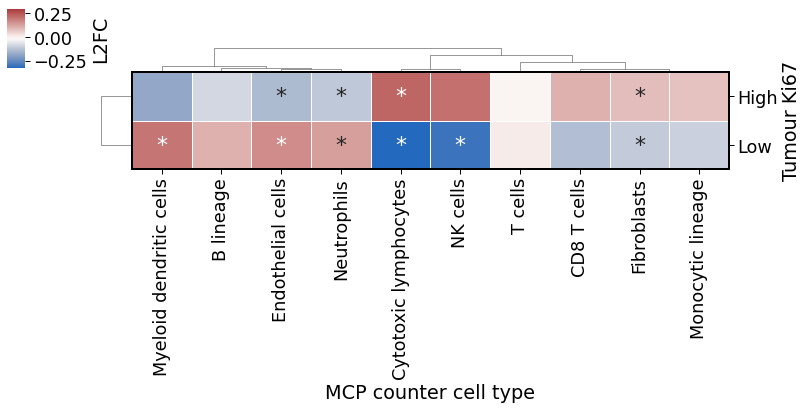

In [84]:
change_data, annot_text = enrichment_test_by_phenotype(data=cell_estimates, phenotype_cols=[col for col in cell_estimates.columns if col != 'panck ki67 high'], meta_col='panck ki67 high')

from matplotlib.patches import Rectangle

g = sns.clustermap(change_data,
               vmin=0.3, vmax=-0.3,
               cmap='vlag',
               dendrogram_ratio=(.05, .2),
               cbar_pos=(-0.1, .895, .025, .15),
               cbar_kws={'label':'L2FC'},
               annot=annot_text,
               fmt="",
               annot_kws={'fontsize':22},
               figsize=(10,5.5))

n_rows, n_cols = change_data.shape
g.ax_heatmap.collections[0].set_linewidth(.5)

rect = Rectangle(
    xy=(0, 0),  # Lower left corner
    width=n_cols,
    height=n_rows,
    fill=False,
    edgecolor='black',
    linewidth=2,
    clip_on=False
)

g.ax_heatmap.add_patch(rect)
g.ax_heatmap.set_yticklabels(['High', 'Low'], rotation=0)
g.ax_heatmap.set_ylabel('Tumour Ki67')
g.ax_heatmap.set_xlabel('MCP counter cell type')